In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
import ast 

## 1ere section : analyse du dataset (arxiv)

à l'issue de ce notebook nous aurons l'occasion de parcourir ce dataset, de traiter l'étendu des données le constituant (données textuelles précisèment), les transformer et appliquer un problème de ML dessus

le dataset : arXiv paper abstract dataset for building multi-label text classifiers. // https://www.kaggle.com/datasets/spsayakpaul/arxiv-paper-abstracts/data 


In [ ]:
def charger_dataset(chemin_dataset : str = "./data/arxiv_data.csv"):
    #chemin par défaut renvoie au dataset avec abstract 
    return pd.read_csv(chemin_dataset)

df = charger_dataset()
df.describe()

,titles,summaries,terms
count,51774,51774,51774
unique,38972,38979,3157
top,Transformers in Vision: A Survey,Astounding results from Transformer models on ...,['cs.CV']
freq,7,7,17369


### Analyse des données du dataset 

Nombre total de documents : 51774
Colonnes disponibles : ['titles', 'summaries', 'terms']
Valeurs manquantes par colonne :
titles       0
summaries    0
terms        0
dtype: int64
Nombre de catégories uniques : 3157
Distribution des catégories (top 10) :
terms
['cs.CV']                        17369
['cs.LG', 'stat.ML']              5251
['cs.LG']                         2732
['cs.CV', 'cs.LG']                2067
['cs.LG', 'cs.AI']                1702
['cs.LG', 'cs.AI', 'stat.ML']     1470
['stat.ML', 'cs.LG']              1376
['cs.CV', 'cs.AI']                 939
['cs.CV', 'cs.LG', 'eess.IV']      855
['cs.CV', 'eess.IV']               769
Name: count, dtype: int64
nombre réel de catégories unique :  1099  => catégories : 
  {'q-bio.GN', 'cs.ET', 'I.4; I.2.10', '65D18, 68U10', 'J.2.4; J.3.1', '62H22, 62R01, 62J99', 'J.2; I.2.m', 'I.4.9; I.5.4; I.2.10', '62G20, 68T05', '68T42', '65D19, 68T45', 'I.2.10; I.3.5', '68T04', '60L10', 'cs.CG', '68T07 (Primary) 68Q55 (Secondary)', 'I.2.5, G

Text(0, 0.5, 'Nombre de documents')

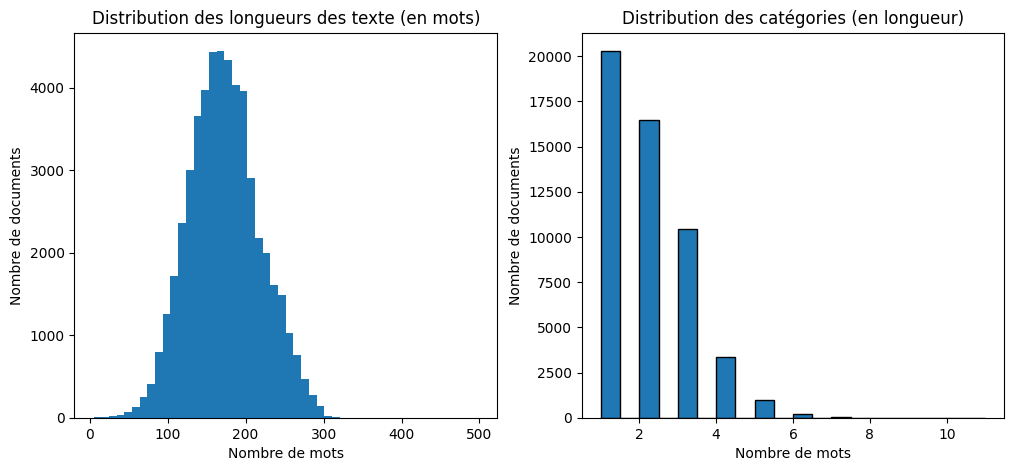

In [ ]:
num_documents = df.shape[0]
print(f"Nombre total de documents : {num_documents}")

colonnes = df.columns.tolist()
print(f"Colonnes disponibles : {colonnes}")

valeurs_manquantes = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(valeurs_manquantes)

colonne_categories = 'terms'  
colonnes_texte = 'summaries'  

### Region 1 : analyse des catégories : terms 


num_categories = df[colonne_categories].nunique()
print(f"Nombre de catégories uniques : {num_categories}")

distribution_categories = df[colonne_categories].value_counts()
print("Distribution des catégories (top 10) :")
print(distribution_categories.head(10))



ensemble_categories = set()
for categories_str in df[colonne_categories]:
    #convertir la chaine et liste 
    categories_list = ast.literal_eval(categories_str) 
    ensemble_categories.update(categories_list)
        

print("nombre réel de catégories unique : ",len(ensemble_categories)," => catégories : \n ",ensemble_categories)

df["longueur_categories"] = df[colonne_categories].apply(lambda x : len(ast.literal_eval(x)))
moyenne_labels_par_doc = df["longueur_categories"].mean()
max_labels_par_doc = df["longueur_categories"].max()
print(f"Nombre moyen de labels par document : {moyenne_labels_par_doc}")
print(f"Nombre maximum de labels par document : {max_labels_par_doc}")


## 2 : analyse de la colonne texte  

df["longueur_texte"] = df[colonnes_texte].astype(str).str.split().apply(len)
longueur_moyenne = df["longueur_texte"].mean()
longueur_mediane = df["longueur_texte"].median()
longueur_min = df["longueur_texte"].min()
longueur_max = df["longueur_texte"].max()
print(f"Longueur moyenne des abstracts (mots) : {longueur_moyenne}")
print(f"Longueur médiane des abstracts (mots) : {longueur_mediane}")
print(f"Longueur minimale : {longueur_min}, maximale : {longueur_max}")
 
 
fig, graphiques = plt.subplots(1, 2, figsize=(12, 5))
graphiques[0].hist(df["longueur_texte"], bins=50)
graphiques[0].set_title('Distribution des longueurs des texte (en mots)')
graphiques[0].set_xlabel('Nombre de mots')
graphiques[0].set_ylabel('Nombre de documents')

graphiques[1].hist(df["longueur_categories"], bins=20, edgecolor='black')
graphiques[1].set_title('Distribution des catégories (en longueur)')
graphiques[1].set_xlabel('Nombre de mots')
graphiques[1].set_ylabel('Nombre de documents')

In [ ]:
df = df.drop_duplicates(subset=["titles","summaries"]).reset_index(drop=True)
df.shape 

(38985, 5)

première analyse à chaud : difficultés quant au nombre de catégories distinctes 1099 => à voir si on en garde que les top-k plus fréquentes ? 

MultiLabelClassification ? avec seuillage sur une sigmoide à la fin (ou garder softmax sur une seule sortie seuleemnt parmi plusieurs labels ???) 

Stratégie : oneVsRest/ All , classe CS et le reste .... et ensuite physique et le reste (y compris CS ...) ??? wrapper autour d'un classifier offert par scikit 
mais on traite pas les similarités entre catégories ??? car nous supposons que les labels sont indépendants, optimisation en ajoutant les prédictions dans les features si jamais ??? à explorer le classifierChain ? 
p(X)=ML , seconde préd P(X+ML)= CV ? 



## 2. Traitement et Transformation du Texte

Dans cette section, nous allons explorer les techniques de traitement du texte en utilisant scikit-learn, en suivant le tutoriel officiel : https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html#tutorial-setup

Nous allons appliquer ces techniques sur notre dataset arXiv pour extraire des caractéristiques numériques des textes.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\alime\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alime\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\alime\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\alime\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### A. Extraction de caractéristiques à partir de fichiers texte - Sacs de mots (Bags of Words)

Le moyen le plus intuitif de transformer le texte en vecteur est d'utiliser une représentation en sacs de mots :

1. Attribuer un identifiant entier fixe à chaque mot apparaissant dans n'importe quel document de l'ensemble d'entraînement (par exemple en construisant un dictionnaire de mots vers indices entiers).
2. Pour chaque document #i, compter le nombre d'occurrences de chaque mot w et le stocker dans X[i, j] comme valeur de la caractéristique #j où j est l'index du mot w dans le dictionnaire.

Cette approche ignore l'ordre des mots et se concentre uniquement sur leur fréquence.

In [ ]:
MAX_FEATURES = 5000 ; MIN_DF = 100 ; MAX_DF = 0.8
configuration_vectorizer = {"max_features":MAX_FEATURES,"stop_words":"english","min_df":MIN_DF,"max_df":MAX_DF,"lowercase":True}
count_vectorizer = CountVectorizer(**configuration_vectorizer)

print("\n--- Lancement du vectorizer sur dataset arxiv (summariess) ---")
summaries_liste = df['summaries'].tolist()

X_arxiv_summaries = count_vectorizer.fit_transform(summaries_liste)
print("Vocabulaire taille finale du dataset:", len(count_vectorizer.get_feature_names_out()))
print("matrice finale forme:", X_arxiv_summaries.shape)
print("Exemple de caractéristiques pour le premier document:")




--- Lancement du vectorizer sur dataset arxiv (summariess) ---
Vocabulaire taille finale du dataset: 3632
matrice finale forme: (38985, 3632)
Exemple de caractéristiques pour le premier document:


### Remarque : 
avec une configuration de base injectée dans le vectorizer : on se retrouve avec un vocabulaire de 12368

min_df = 10 : nombre occurence minimal des mots est de 10 dans tout le corpus 
max_df 0.8 : si trop fréquent alors dans ce cas on se retrouve avec des mots trop fréquents dans ce cas alors on dévide de pas traiter ces mots ( comme paper ....)

### C. Prétraitement avec Lemmatisation, Stemmatisation et autres techniques

Le prétraitement avancé du texte va au-delà de la simple tokenisation et du filtrage des mots vides. Nous allons explorer plusieurs techniques importantes :

stemming lemmatisation, etc ... puis comme résultat final on va faire notre fonction de prétraitement, et comparer taille de la matrice à la fin du vectorizer dans les deux cas avec la même configuration. 

In [ ]:
import re
from typing import Literal


def preprocess_texte(texte:str,strategie:Literal["stemmer","lemmatizer"]="lemmatizer") -> str:
    texte = texte.lower().strip()
    texte = re.sub(r'[^\w\s]', '', texte)#gardons seulement lettre chiffre et espace
    tokens = word_tokenize(texte) #premiere tokenization
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words and len(token)>=2 and not token.isdigit()]
    if strategie == "stemmer":
        stemmer_objet = PorterStemmer()
        liste_tokens_propres =  [stemmer_objet.stem(token) for token in tokens]
    elif strategie == "lemmatizer":
        lemmatizer_objet = WordNetLemmatizer()
        liste_tokens_propres =  [lemmatizer_objet.lemmatize(token) for token in tokens]
    else  :
        raise NotImplementedError("pas d'implémentation sur autre approchess")
        liste_tokens_propres = []
    
    if liste_tokens_propres is not None : 
        return " ".join(liste_tokens_propres)
    

#test de la méthode 

texte_random = "there is nothing that can handle this paper i can't even imagine"
texte_cleaned = preprocess_texte(texte_random)
print("texte_cleand : " , texte_cleaned)


# df["summaries_nettoye"]= df["summaries"].apply(preprocess_texte)

texte_cleand :  nothing handle paper cant even imagine


In [8]:
""" application du vectorizer directement """

df["summaries_nettoye"]=df["summaries"].apply(preprocess_texte)
summaries_cleaned_liste = df["summaries_nettoye"].tolist()
X_arxiv_summaries_nettoye = count_vectorizer.fit_transform(summaries_cleaned_liste)
print("Vocabulaire taille finale du dataset:", len(count_vectorizer.get_feature_names_out()))
print("matrice finale forme:", X_arxiv_summaries_nettoye.shape)
print("Exemple de caractéristiques pour le premier document:")

Vocabulaire taille finale du dataset: 3149
matrice finale forme: (38985, 3149)
Exemple de caractéristiques pour le premier document:


### Observation : 
pas de changement majeur sur la taille du vocabulaire .... 

In [9]:
tfidf_vectorizer = TfidfVectorizer(**configuration_vectorizer)

def vectorizer_simple(liste : str , vectorizer_type:Literal["countVectorizer","tfidfVectorizer"]="countVectorizer"): 
    if vectorizer_type == "countVectorizer" : 
        X_arxiv_summaries_nettoye = count_vectorizer.fit_transform(liste)
        print("Vocabulaire taille finale du dataset:", len(count_vectorizer.get_feature_names_out()))
        print("matrice finale forme:", X_arxiv_summaries_nettoye.shape)
    elif vectorizer_type == "tfidfVectorizer" : 
        X_arxiv_summaries_nettoye = tfidf_vectorizer.fit_transform(liste)
        vocabulaire = tfidf_vectorizer.get_feature_names_out()
        idf_scores = tfidf_vectorizer.idf_
        top_terms = sorted(zip(vocabulaire, idf_scores), key=lambda x: x[1], reverse=True)[:10]
        for term, idf in top_terms:
            print(f"{term}: {idf}")
        print("matrice finale forme:", X_arxiv_summaries_nettoye.shape)
        X_arxiv_summaries_nettoye = normalize(X_arxiv_summaries_nettoye, norm='l2')
    return X_arxiv_summaries_nettoye


liste_vectorizer_tf_idf = vectorizer_simple(df["summaries_nettoye"].tolist(),'tfidfVectorizer')

assigns: 6.955837369464831
atom: 6.955837369464831
circumvent: 6.955837369464831
default: 6.955837369464831
disjoint: 6.955837369464831
ecommerce: 6.955837369464831
eigenvalue: 6.955837369464831
emerge: 6.955837369464831
examination: 6.955837369464831
formalism: 6.955837369464831
matrice finale forme: (38985, 3149)


In [10]:
# ============================================================
# EMBEDDING APPROACH : GloVe (Global Vectors for Word Representation)
# ============================================================

import numpy as np
import urllib.request
import zipfile
import os
from tqdm import tqdm


In [11]:

# --- 1. Téléchargement et chargement des vecteurs GloVe ---

GLOVE_URL = "https://nlp.stanford.edu/data/glove.6B.zip"
GLOVE_DIR = "./glove"
GLOVE_FILE = os.path.join(GLOVE_DIR, "glove.6B.300d.txt")  # 300 dimensions

# Téléchargement si nécessaire
if not os.path.exists(GLOVE_FILE):
    os.makedirs(GLOVE_DIR, exist_ok=True)
    print("Téléchargement de GloVe (822 MB)...")
    urllib.request.urlretrieve(GLOVE_URL, os.path.join(GLOVE_DIR, "glove.6B.zip"))
    with zipfile.ZipFile(os.path.join(GLOVE_DIR, "glove.6B.zip"), "r") as z:
        z.extractall(GLOVE_DIR)
    print("Téléchargement terminé.")

def charger_glove(chemin: str) -> dict:
    """Charge les vecteurs GloVe dans un dictionnaire mot -> vecteur numpy."""
    embeddings = {}
    with open(chemin, "r", encoding="utf-8") as f:
        for ligne in f:
            valeurs = ligne.split()
            mot = valeurs[0]
            vecteur = np.array(valeurs[1:], dtype=np.float32)
            embeddings[mot] = vecteur
    print(f"GloVe chargé : {len(embeddings)} mots, dimension {len(next(iter(embeddings.values())))}")
    return embeddings

glove_embeddings = charger_glove(GLOVE_FILE)
EMBEDDING_DIM = 300


GloVe chargé : 400000 mots, dimension 300


In [12]:
def document_vers_vecteur_glove(texte: str, embeddings: dict, dim: int = EMBEDDING_DIM) -> np.ndarray:
    tokens = texte.split()
    vecteurs = [embeddings[mot] for mot in tokens if mot in embeddings]
    
    if vecteurs:
        return np.mean(vecteurs, axis=0)
    else:
        return np.zeros(dim)

# Application sur les summaries nettoyées
print("Vectorisation GloVe en cours...")

docs_faible_couverture = []  # on collecte au lieu de print dans la boucle

X_glove = []
for texte in tqdm(df["summaries_nettoye"]):
    tokens = texte.split()
    vecteurs = [glove_embeddings[mot] for mot in tokens if mot in glove_embeddings]
    tokens_absents = [mot for mot in tokens if mot not in glove_embeddings]
    
    ratio = len(vecteurs) / len(tokens) if tokens else 0
    if ratio < 0.8:
        docs_faible_couverture.append({
            "ratio": ratio,
            "tokens_absents": tokens_absents
        })
    
    if vecteurs:
        X_glove.append(np.mean(vecteurs, axis=0))
    else:
        X_glove.append(np.zeros(EMBEDDING_DIM))

X_glove = np.vstack(X_glove)

# Rapport post-boucle
print(f"\nForme de la matrice GloVe : {X_glove.shape}")
print(f"Documents avec couverture < 80% : {len(docs_faible_couverture)} "
      f"({len(docs_faible_couverture)/len(df)*100:.2f}%)")

# Inspection des cas problématiques (les 10 pires)
if docs_faible_couverture:
    pires = sorted(docs_faible_couverture, key=lambda x: x["ratio"])[:10]
    print("\nTop 10 documents avec la plus faible couverture :")
    for d in pires:
        print(f"  ratio={d['ratio']:.2f} | absents={d['tokens_absents'][:8]}")

# Juste après avoir calculé X_glove par moyenne simple, renomme-le
X_glove_mean = X_glove.copy()


Vectorisation GloVe en cours...


100%|██████████| 38985/38985 [00:03<00:00, 12524.38it/s]



Forme de la matrice GloVe : (38985, 300)
Documents avec couverture < 80% : 141 (0.36%)

Top 10 documents avec la plus faible couverture :
  ratio=0.54 | absents=['derin', 'pekistirmeli', 'ogrenme', 'navigasyonu', 'otomatiklestirilmis', 'oyunu', 'oynama', 'gibi']
  ratio=0.64 | absents=['semisupervised', 'artigo', 'apresenta', 'proposta', 'extensao', 'aprendizado', 'semisupervisionado', 'conhecido']
  ratio=0.65 | absents=['lanalyse', 'destimer', 'tendances', 'evenements', 'futurs', 'algorithmes', 'permettent', 'cependant']
  ratio=0.72 | absents=['valuebased', 'reinforcementlearning', 'stateoftheart', 'modelfree', 'discreteaction', 'actorcritic', 'actorcritic', 'onpolicy']
  ratio=0.73 | absents=['latticefree', 'lfmmi', 'selfsupervised', 'pretrained', 'pretrain', 'untranscribed', 'librispeech', 'lfmmi']
  ratio=0.73 | absents=['determinantal', 'dpps', 'gve', 'mathbfa', 'spanningtree', 'ssubseteq', 'detmathbfa_s', 'sharptextsfphardness']
  ratio=0.73 | absents=['meanvariance', 'mvpi', 

In [13]:
# Création et entraînement du TfidfVectorizer sur les textes nettoyés
print("Entraînement du TfidfVectorizer pour GloVe pondéré...")
tfidf_vectorizer_glove = TfidfVectorizer(**configuration_vectorizer)
tfidf_matrix = tfidf_vectorizer_glove.fit_transform(df["summaries_nettoye"])
feature_names = tfidf_vectorizer_glove.get_feature_names_out()

def document_vers_vecteur_glove_tfidf(doc_index: int, tfidf_matrix, feature_names: np.ndarray, 
                                       embeddings: dict, dim: int = EMBEDDING_DIM) -> np.ndarray:
    """Vectorise un document avec TF-IDF pondéré sur les embeddings GloVe."""
    # Récupérer la ligne sparse du document
    doc_tfidf = tfidf_matrix[doc_index]
    
    # Initialiser le vecteur résultat
    vecteur_resultat = np.zeros(dim, dtype=np.float32)
    
    # Parcourir les éléments non-nuls (sparse)
    for idx, tfidf_score in zip(doc_tfidf.indices, doc_tfidf.data):
        mot = feature_names[idx]
        if mot in embeddings:
            vecteur_resultat += tfidf_score * embeddings[mot]
    
    return vecteur_resultat

# Application sur les summaries nettoyées
print("Vectorisation GloVe avec TF-IDF en cours...")

docs_faible_couverture = []  # on collecte au lieu de print dans la boucle

X_glove = []
for doc_idx in tqdm(range(len(df))):
    texte = df["summaries_nettoye"].iloc[doc_idx]
    tokens = texte.split()
    vecteurs_glove_count = sum(1 for mot in tokens if mot in glove_embeddings)
    tokens_absents = [mot for mot in tokens if mot not in glove_embeddings]
    
    ratio = vecteurs_glove_count / len(tokens) if tokens else 0
    if ratio < 0.8:
        docs_faible_couverture.append({
            "ratio": ratio,
            "tokens_absents": tokens_absents
        })
    
    # Vectorisation avec TF-IDF pondéré
    vec = document_vers_vecteur_glove_tfidf(doc_idx, tfidf_matrix, feature_names, glove_embeddings)
    X_glove.append(vec)

X_glove = np.vstack(X_glove)

# Rapport post-boucle
print(f"\nForme de la matrice GloVe (TF-IDF pondéré) : {X_glove.shape}")
print(f"Documents avec couverture < 80% : {len(docs_faible_couverture)} "
      f"({len(docs_faible_couverture)/len(df)*100:.2f}%)")

# Inspection des cas problématiques (les 100 pires)
if docs_faible_couverture:
    pires = sorted(docs_faible_couverture, key=lambda x: x["ratio"])[:100]
    print("\nTop 100 documents avec la plus faible couverture :")
    for d in pires:
        print(f"  ratio={d['ratio']:.2f} | absents={d['tokens_absents'][:8]}")
# Puis exécute le code TF-IDF qui produit X_glove
# ...
X_glove_tfidf = X_glove.copy()

Entraînement du TfidfVectorizer pour GloVe pondéré...
Vectorisation GloVe avec TF-IDF en cours...


100%|██████████| 38985/38985 [00:14<00:00, 2638.66it/s]


Forme de la matrice GloVe (TF-IDF pondéré) : (38985, 300)
Documents avec couverture < 80% : 141 (0.36%)

Top 100 documents avec la plus faible couverture :
  ratio=0.54 | absents=['derin', 'pekistirmeli', 'ogrenme', 'navigasyonu', 'otomatiklestirilmis', 'oyunu', 'oynama', 'gibi']
  ratio=0.64 | absents=['semisupervised', 'artigo', 'apresenta', 'proposta', 'extensao', 'aprendizado', 'semisupervisionado', 'conhecido']
  ratio=0.65 | absents=['lanalyse', 'destimer', 'tendances', 'evenements', 'futurs', 'algorithmes', 'permettent', 'cependant']
  ratio=0.72 | absents=['valuebased', 'reinforcementlearning', 'stateoftheart', 'modelfree', 'discreteaction', 'actorcritic', 'actorcritic', 'onpolicy']
  ratio=0.73 | absents=['latticefree', 'lfmmi', 'selfsupervised', 'pretrained', 'pretrain', 'untranscribed', 'librispeech', 'lfmmi']
  ratio=0.73 | absents=['determinantal', 'dpps', 'gve', 'mathbfa', 'spanningtree', 'ssubseteq', 'detmathbfa_s', 'sharptextsfphardness']
  ratio=0.73 | absents=['meanv

## les mot non reconnu represnete des terme scientific 

In [14]:

# --- 3. Analyse de couverture vocabulaire ---

def taux_couverture_glove(textes, embeddings):
    """Calcule le % de tokens du corpus couverts par GloVe."""
    total, couverts = 0, 0
    for texte in textes:
        tokens = texte.split()
        total += len(tokens)
        couverts += sum(1 for t in tokens if t in embeddings)
    return couverts / total * 100 if total > 0 else 0

couverture = taux_couverture_glove(df["summaries_nettoye"], glove_embeddings)
print(f"Couverture vocabulaire GloVe : {couverture:.2f}%")


Couverture vocabulaire GloVe : 93.69%


In [15]:

# --- 4. Comparaison des représentations ---

print("\n--- Comparaison des approches d'embedding ---")
print(f"Bag-of-Words (CountVectorizer) : {X_arxiv_summaries_nettoye.shape} (sparse, {X_arxiv_summaries_nettoye.shape[1]} features)")
print(f"GloVe (moyenne)               : {X_glove.shape} (dense, {EMBEDDING_DIM} features)")


--- Comparaison des approches d'embedding ---
Bag-of-Words (CountVectorizer) : (38985, 3149) (sparse, 3149 features)
GloVe (moyenne)               : (38985, 300) (dense, 300 features)


In [16]:
# ============================================================
# CLUSTERING SUR LES EMBEDDINGS GLOVE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# X_glove : matrice (n_docs, 100) obtenue précédemment
# Normalisation L2 recommandée pour la distance cosine
X_glove_norm = normalize(X_glove, norm='l2')


Réduction dimensionnelle PCA...


Variance expliquée par les 50 composantes : 70.22%
Forme après PCA : (38985, 50)

Recherche du k optimal (sur données réduites PCA)...
  k= 2 | Silhouette:  0.1070 | Davies-Bouldin:  2.8035 | Calinski:  4923.27
  k= 3 | Silhouette:  0.0919 | Davies-Bouldin:  2.6836 | Calinski:  3928.88
  k= 4 | Silhouette:  0.0811 | Davies-Bouldin:  2.9189 | Calinski:  3159.66


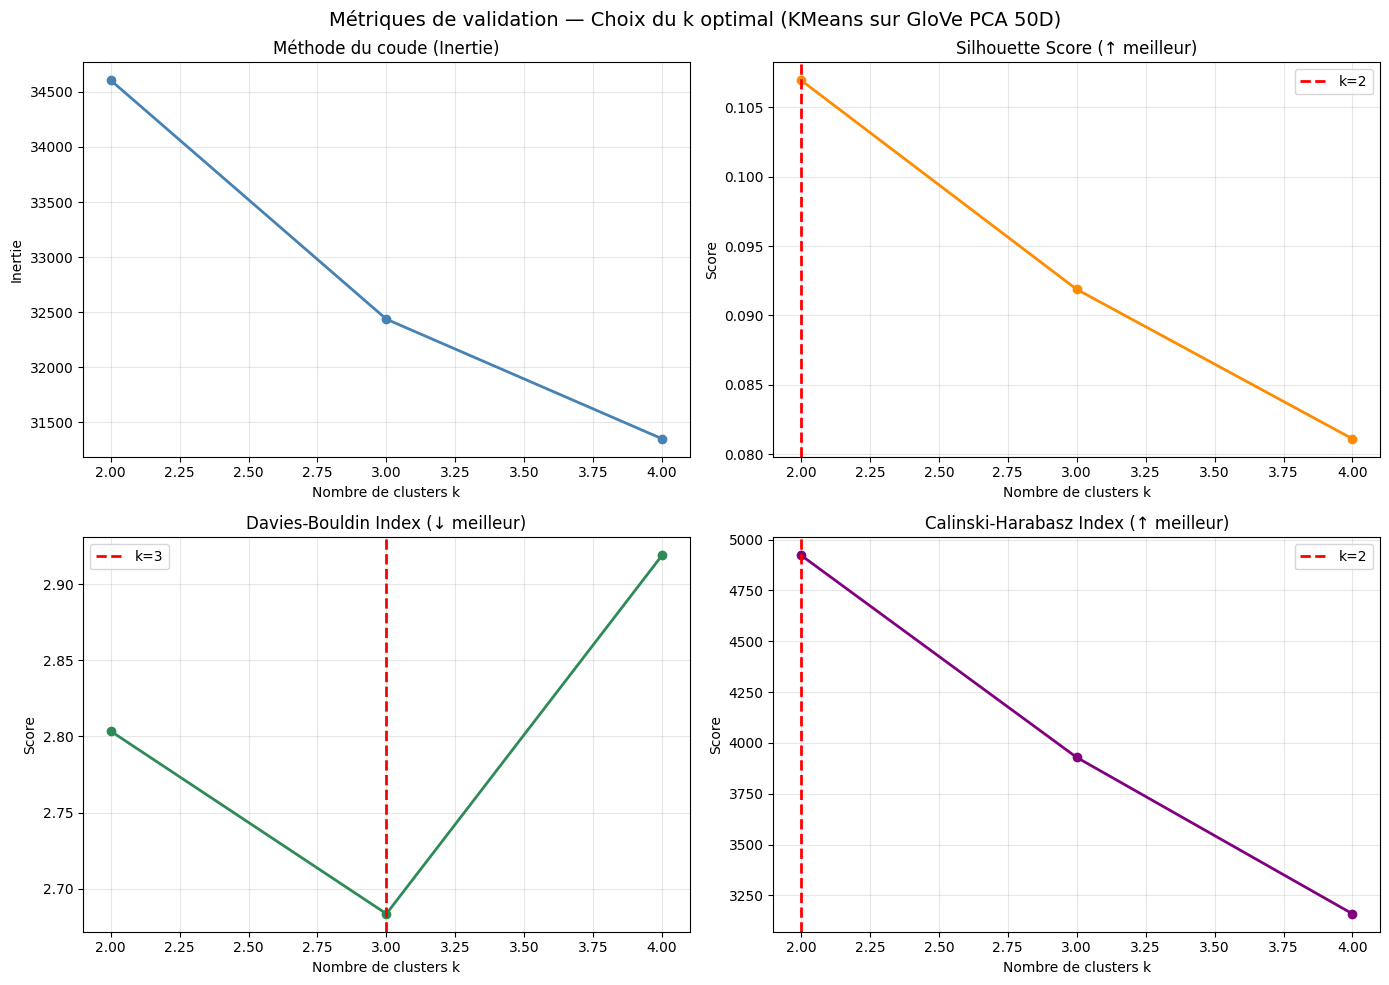


Meilleur k selon Silhouette : 2
Meilleur k selon Davies-Bouldin : 3
Meilleur k selon Calinski-Harabasz : 2


In [17]:


# ============================================================
# PARTIE 0.5 : RÉDUCTION DIMENSIONNELLE (critique pour GloVe)
# ============================================================

print("Réduction dimensionnelle PCA...")
pca_optimal = PCA(n_components=50, random_state=42)  # 50D au lieu de 300D
X_glove_pca = pca_optimal.fit_transform(X_glove)
X_glove_pca = normalize(X_glove_pca, norm='l2')

print(f"Variance expliquée par les 50 composantes : {pca_optimal.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Forme après PCA : {X_glove_pca.shape}")

# ============================================================
# PARTIE 1 : K-MEANS — Choix du k optimal (méthode du coude)
# ============================================================

K_RANGE = range(2, 5)
inertias = []
silhouettes = []
davies_bouldins = []
calinskis = []

print("\nRecherche du k optimal (sur données réduites PCA)...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=15, max_iter=500)
    labels = km.fit_predict(X_glove_pca)
    
    inertias.append(km.inertia_)
    sil = silhouette_score(X_glove_pca, labels)
    db = davies_bouldin_score(X_glove_pca, labels)
    ch = calinski_harabasz_score(X_glove_pca, labels)
    
    silhouettes.append(sil)
    davies_bouldins.append(db)
    calinskis.append(ch)
    
    print(f"  k={k:2d} | Silhouette: {sil:7.4f} | Davies-Bouldin: {db:7.4f} | Calinski: {ch:8.2f}")

# Visualisation des métriques
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Métriques de validation — Choix du k optimal (KMeans sur GloVe PCA 50D)", fontsize=14)

axes[0,0].plot(K_RANGE, inertias, 'o-', color='steelblue', linewidth=2)
axes[0,0].set_title("Méthode du coude (Inertie)")
axes[0,0].set_xlabel("Nombre de clusters k")
axes[0,0].set_ylabel("Inertie")
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(K_RANGE, silhouettes, 'o-', color='darkorange', linewidth=2)
axes[0,1].set_title("Silhouette Score (↑ meilleur)")
axes[0,1].set_xlabel("Nombre de clusters k")
axes[0,1].set_ylabel("Score")
best_k_sil = np.argmax(silhouettes) + min(K_RANGE)
axes[0,1].axvline(best_k_sil, linestyle='--', color='red', linewidth=2, label=f"k={best_k_sil}")
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

axes[1,0].plot(K_RANGE, davies_bouldins, 'o-', color='seagreen', linewidth=2)
axes[1,0].set_title("Davies-Bouldin Index (↓ meilleur)")
axes[1,0].set_xlabel("Nombre de clusters k")
axes[1,0].set_ylabel("Score")
best_k_db = np.argmin(davies_bouldins) + min(K_RANGE)
axes[1,0].axvline(best_k_db, linestyle='--', color='red', linewidth=2, label=f"k={best_k_db}")
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(K_RANGE, calinskis, 'o-', color='purple', linewidth=2)
axes[1,1].set_title("Calinski-Harabasz Index (↑ meilleur)")
axes[1,1].set_xlabel("Nombre de clusters k")
axes[1,1].set_ylabel("Score")
best_k_ch = np.argmax(calinskis) + min(K_RANGE)
axes[1,1].axvline(best_k_ch, linestyle='--', color='red', linewidth=2, label=f"k={best_k_ch}")
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMeilleur k selon Silhouette : {best_k_sil}")
print(f"Meilleur k selon Davies-Bouldin : {best_k_db}")
print(f"Meilleur k selon Calinski-Harabasz : {best_k_ch}")


In [18]:
# ============================================================
# PARTIE 2 : K-MEANS + Alternatives — VERSION OPTIMISÉE
# ============================================================

from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN, MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors

K_OPTIMAL = best_k_db
print(f"K optimal retenu : {K_OPTIMAL} (selon Davies-Bouldin)")

# ============================================================
# KMeans → MiniBatchKMeans : même résultat, 10x plus rapide
# ============================================================
print("\n[1/3] MiniBatchKMeans...")
kmeans = MiniBatchKMeans(
    n_clusters=K_OPTIMAL,
    random_state=42,
    n_init=10,
    batch_size=2048,
    max_iter=300
)
labels_kmeans = kmeans.fit_predict(X_glove_pca)  # sur tout le corpus
df["cluster_kmeans"] = labels_kmeans

# ============================================================
# GMM → sur corpus complet
# ============================================================
print("[2/3] GaussianMixture (sur corpus complet)...")
gmm = GaussianMixture(
    n_components=K_OPTIMAL,
    random_state=42,
    n_init=3,        # réduit de 10 à 3
    covariance_type='diag',  # CRITIQUE : 'full' est O(d²), 'diag' est O(d)
    max_iter=100
)
labels_gmm = gmm.fit_predict(X_glove_pca)
df["cluster_gmm"] = labels_gmm

# ============================================================
# DBSCAN → sur corpus complet + eps via percentile
# ============================================================
print("[3/3] DBSCAN (sur corpus complet)...")
nn = NearestNeighbors(n_neighbors=5, n_jobs=-1)
nn.fit(X_glove_pca)
distances, _ = nn.kneighbors(X_glove_pca)
distances_sorted = np.sort(distances[:, -1])
eps_optimal = np.percentile(distances_sorted, 90)
print(f"  Eps optimal : {eps_optimal:.4f}")

dbscan = DBSCAN(eps=eps_optimal, min_samples=5, n_jobs=-1)
labels_dbscan = dbscan.fit_predict(X_glove_pca)
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)
print(f"  Clusters trouvés : {n_clusters_dbscan} | Bruit : {n_noise} docs")

df["cluster_dbscan"] = labels_dbscan

# ============================================================
# COMPARAISON MÉTRIQUES — sur corpus complet
# ============================================================

print("\n" + "="*80)
print("COMPARAISON DES ALGORITHMES (sur corpus complet)")
print("="*80)
print(f"{'Algo':<20} {'Clusters':>9} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski':>12}")
print("-"*80)

comparison_data = []
for algo_name, labels in [
    ("MiniBatchKMeans", labels_kmeans),
    ("GMM (diag)",      labels_gmm),
    ("DBSCAN",          labels_dbscan),
]:
    try:
        n_clust = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clust < 2:
            print(f"{algo_name:<20} | Trop peu de clusters ({n_clust}) — skip")
            continue
        # Filtrer le bruit DBSCAN pour les métriques
        mask = labels != -1
        X_eval = X_glove_pca[mask] if algo_name == "DBSCAN" else X_glove_pca
        l_eval = labels[mask]    if algo_name == "DBSCAN" else labels

        sil = silhouette_score(X_eval, l_eval, sample_size=2000)
        db  = davies_bouldin_score(X_eval, l_eval)
        ch  = calinski_harabasz_score(X_eval, l_eval)
        comparison_data.append([algo_name, n_clust, sil, db, ch])
        print(f"{algo_name:<20} {n_clust:>9} {sil:>12.4f} {db:>16.4f} {ch:>12.2f}")
    except Exception as e:
        print(f"{algo_name:<20} | Erreur : {e}")

print("="*80)

# Distribution KMeans (corpus complet)
print("\n--- Distribution KMeans (corpus complet) ---")
print(df["cluster_kmeans"].value_counts().sort_index())

print("\n--- Distribution DBSCAN (corpus complet) ---")
print(f"Clusters : {n_clusters_dbscan} | Bruit : {n_noise} docs ({n_noise/len(X_glove_pca)*100:.1f}%)")

K optimal retenu : 3 (selon Davies-Bouldin)

[1/3] MiniBatchKMeans...
[2/3] GaussianMixture (sur échantillon)...
[3/3] DBSCAN (sur échantillon)...
  Eps optimal : 0.9642
  Clusters trouvés : 1 | Bruit : 140 docs

COMPARAISON DES ALGORITHMES (sur échantillon n=5000)
Algo                  Clusters   Silhouette   Davies-Bouldin     Calinski
--------------------------------------------------------------------------------
MiniBatchKMeans              3       0.0883           2.7910       492.04
GMM (diag)                   3       0.0177           3.5573       270.20
DBSCAN               | Trop peu de clusters (1) — skip

--- Distribution KMeans (corpus complet) ---
cluster_kmeans
0    14761
1    11528
2    12696
Name: count, dtype: int64

--- Distribution DBSCAN (échantillon) ---
Clusters : 1 | Bruit : 140 docs (2.8%)


In [19]:
K_RANGE = [2, 3]

resultats = {}

for nom, X in [("GloVe moyenne", X_glove_mean), ("GloVe TF-IDF", X_glove_tfidf)]:
    X_norm = normalize(X, norm='l2')
    for k in K_RANGE:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_norm)
        
        cle = f"{nom} | k={k}"
        resultats[cle] = {
            "labels": labels,
            "silhouette": silhouette_score(X_norm, labels, sample_size=3000),
            "davies_bouldin": davies_bouldin_score(X_norm, labels),
            "calinski": calinski_harabasz_score(X_norm, labels),
        }

# Tableau comparatif
print(f"\n{'Méthode':<30} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-Harabasz':>18}")
print("-" * 80)
for cle, r in resultats.items():
    print(f"{cle:<30} {r['silhouette']:>12.4f} {r['davies_bouldin']:>16.4f} {r['calinski']:>18.2f}")

print("\nInterprétation :")
meilleur_sil = max(resultats, key=lambda x: resultats[x]['silhouette'])
meilleur_db  = min(resultats, key=lambda x: resultats[x]['davies_bouldin'])
print(f"  Silhouette (↑)     → meilleur : {meilleur_sil}")
print(f"  Davies-Bouldin (↓) → meilleur : {meilleur_db}")


Méthode                Silhouette   Davies-Bouldin  Calinski-Harabasz
----------------------------------------------------------------------
GloVe moyenne              0.0503           3.6935            2280.82
GloVe TF-IDF               0.0480           3.9568            2214.38

Interprétation :
  Silhouette (↑)    → meilleur : GloVe moyenne
  Davies-Bouldin (↓) → meilleur : GloVe moyenne



Clustering hiérarchique sur 2000 documents (sur X_glove_pca)...


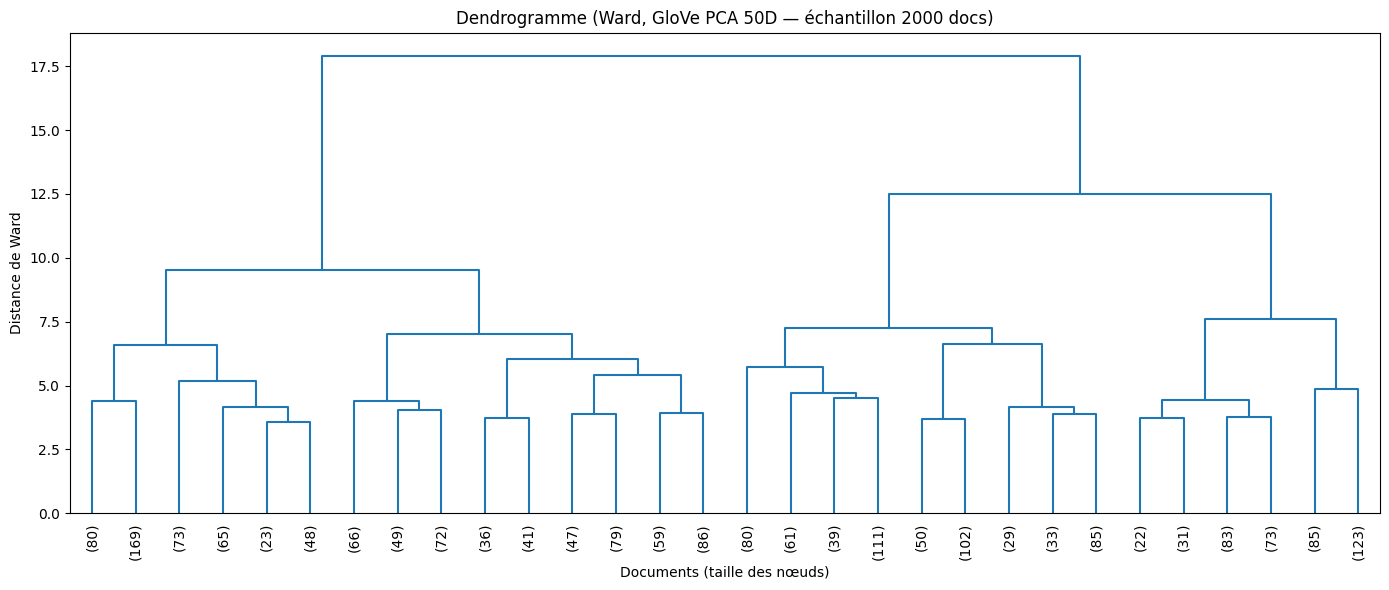


Clustering hiérarchique complet avec K_OPTIMAL=3 clusters...

[Hiérarchique — échantillon] Silhouette: 0.0488 | Davies-Bouldin: 3.4012 | Calinski: 126.04
[Hiérarchique — complet]   Silhouette: 0.0513 | Davies-Bouldin: 3.2968 | Calinski: 2540.24

--- Distribution Clustering Hiérarchique ---
cluster_hierarchical
0    19515
1    10669
2     8801
Name: count, dtype: int64


In [20]:
# ============================================================
# PARTIE 3 : CLUSTERING HIERARCHIQUE (sur données PCA réduites)
# ============================================================

# Sur le corpus complet
N_SAMPLE = len(X_glove_pca)
idx_sample_hier = np.arange(len(X_glove_pca))  # pas de sampling
X_sample_hier = X_glove_pca

# Dendrogramme
print(f"\nClustering hiérarchique sur {len(X_sample_hier)} documents (sur X_glove_pca)...")
Z = linkage(X_sample_hier, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, show_leaf_counts=True, color_threshold=0)
plt.title("Dendrogramme (Ward, GloVe PCA 50D — corpus complet)")
plt.xlabel("Documents (taille des nœuds)")
plt.ylabel("Distance de Ward")
plt.tight_layout()
plt.show()

# Clustering hiérarchique avec k_optimal clusters
print(f"\nClustering hiérarchique complet avec K_OPTIMAL={K_OPTIMAL} clusters...")
agglo = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
labels_agglo_full = agglo.fit_predict(X_glove_pca)
df["cluster_hierarchical"] = labels_agglo_full

# Métriques sur l'ensemble des données
sil_agglo_full = silhouette_score(X_glove_pca, labels_agglo_full)
db_agglo_full = davies_bouldin_score(X_glove_pca, labels_agglo_full)
ch_agglo_full = calinski_harabasz_score(X_glove_pca, labels_agglo_full)

print(f"[Hiérarchique — complet]   Silhouette: {sil_agglo_full:.4f} | Davies-Bouldin: {db_agglo_full:.4f} | Calinski: {ch_agglo_full:.2f}")

# Distribution des clusters
print("\n--- Distribution Clustering Hiérarchique ---")
dist_hier = df["cluster_hierarchical"].value_counts().sort_index()
print(dist_hier)

In [21]:
# ============================================================
# PARTIE 4 : VISUALISATION PCA / t-SNE (sur données réduites)
# ============================================================

N_VIZ = len(X_glove_pca)  # corpus complet
idx_viz = np.arange(len(X_glove_pca))
X_viz = X_glove_pca
labels_viz_km = labels_kmeans
labels_viz_dbscan = labels_dbscan

# PCA 2D (sur les 50D déjà réduits)
pca_2d = PCA(n_components=2, random_state=42)
X_pca2d = pca_2d.fit_transform(X_viz)

# t-SNE 2D
print(f"Calcul t-SNE sur {len(X_viz)} documents...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, n_jobs=-1)
X_tsne = tsne.fit_transform(X_viz)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle(f"Visualisation des clusters GloVe+PCA 50D (n={len(X_viz)} docs)", fontsize=14, fontweight='bold')

# ===== KMeans =====
cmap_km = plt.cm.get_cmap('tab20', K_OPTIMAL)

scatter1 = axes[0,0].scatter(X_pca2d[:,0], X_pca2d[:,1], c=labels_viz_km, cmap=cmap_km, s=5, alpha=0.7, edgecolors='none')
axes[0,0].set_title(f"KMeans (k={K_OPTIMAL}) — PCA 2D")
axes[0,0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
axes[0,0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(scatter1, ax=axes[0,0], label='Cluster')

scatter2 = axes[0,1].scatter(X_tsne[:,0], X_tsne[:,1], c=labels_viz_km, cmap=cmap_km, s=5, alpha=0.7, edgecolors='none')
axes[0,1].set_title(f"KMeans (k={K_OPTIMAL}) — t-SNE 2D")
plt.colorbar(scatter2, ax=axes[0,1], label='Cluster')

# ===== DBSCAN =====
n_dbscan_clusters = len(set(labels_viz_dbscan)) - (1 if -1 in labels_viz_dbscan else 0)
cmap_db = plt.cm.get_cmap('tab20', max(n_dbscan_clusters, 2))

scatter3 = axes[1,0].scatter(X_pca2d[:,0], X_pca2d[:,1], c=labels_viz_dbscan, cmap=cmap_db, s=5, alpha=0.7, edgecolors='none')
noise_mask = labels_viz_dbscan == -1
if noise_mask.any():
    axes[1,0].scatter(X_pca2d[noise_mask, 0], X_pca2d[noise_mask, 1], c='red', s=10, alpha=0.5, marker='x', label='Bruit')
axes[1,0].set_title(f"DBSCAN (eps={eps_optimal:.4f}, clusters={n_dbscan_clusters}) — PCA 2D")
axes[1,0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
axes[1,0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(scatter3, ax=axes[1,0], label='Cluster')
axes[1,0].legend()

scatter4 = axes[1,1].scatter(X_tsne[:,0], X_tsne[:,1], c=labels_viz_dbscan, cmap=cmap_db, s=5, alpha=0.7, edgecolors='none')
if noise_mask.any():
    axes[1,1].scatter(X_tsne[noise_mask, 0], X_tsne[noise_mask, 1], c='red', s=10, alpha=0.5, marker='x', label='Bruit')
axes[1,1].set_title(f"DBSCAN (eps={eps_optimal:.4f}, clusters={n_dbscan_clusters}) — t-SNE 2D")
plt.colorbar(scatter4, ax=axes[1,1], label='Cluster')
axes[1,1].legend()

plt.tight_layout()
plt.show()

NameError: name 'labels_dbscan' is not defined

In [ ]:


# ============================================================
# PARTIE 5 : ANALYSE QUALITATIVE DES CLUSTERS
# ============================================================

from collections import Counter
import ast

def top_mots_cluster(df, cluster_id, col_texte='summaries_nettoye', cluster_col='cluster_kmeans', n=15):
    """Retourne les mots les plus fréquents dans un cluster."""
    mask = df[cluster_col] == cluster_id
    if not mask.any():
        return []
    textes = df[mask][col_texte].tolist()
    tous_mots = ' '.join(textes).split()
    return Counter(tous_mots).most_common(n)

def top_categories_cluster(df, cluster_id, col_cat='terms', cluster_col='cluster_kmeans', n=5):
    """Retourne les catégories ArXiv les plus fréquentes dans un cluster."""
    mask = df[cluster_col] == cluster_id
    if not mask.any():
        return []
    categories_cluster = []
    for cat_str in df[mask][col_cat]:
        try:
            categories_cluster.extend(ast.literal_eval(cat_str))
        except:
            pass
    return Counter(categories_cluster).most_common(n)

print("\n" + "="*100)
print("ANALYSE QUALITATIVE DES CLUSTERS (KMeans)")
print("="*100)

n_clusters_to_analyze = min(K_OPTIMAL, 8)  # Limiter pour la lisibilité
for cid in range(n_clusters_to_analyze):
    n_docs = (labels_kmeans == cid).sum()
    top_mots  = top_mots_cluster(df, cid, cluster_col='cluster_kmeans')
    top_cats  = top_categories_cluster(df, cid, cluster_col='cluster_kmeans')
    
    print(f"\n--- Cluster {cid} ({n_docs} documents) ---")
    if top_mots:
        print(f"  Top mots  : {', '.join([m for m,_ in top_mots])}")
    if top_cats:
        print(f"  Top catég : {', '.join([c for c,_ in top_cats])}")

# === DBSCAN Analysis ===
print("\n" + "="*100)
print("ANALYSE QUALITATIVE DES CLUSTERS (DBSCAN)")
print("="*100)

unique_labels_db = sorted([l for l in set(labels_dbscan) if l != -1])
n_clusters_db_analyze = min(len(unique_labels_db), 8)

for cid in unique_labels_db[:n_clusters_db_analyze]:
    n_docs = (labels_dbscan == cid).sum()
    top_mots  = top_mots_cluster(df, cid, cluster_col='cluster_dbscan')
    top_cats  = top_categories_cluster(df, cid, cluster_col='cluster_dbscan'
                                       )
    
    print(f"\n--- Cluster {cid} ({n_docs} documents) ---")
    if top_mots:
        print(f"  Top mots  : {', '.join([m for m,_ in top_mots])}")
    if top_cats:
        print(f"  Top catég : {', '.join([c for c,_ in top_cats])}")

if -1 in labels_dbscan:
    print(f"\n--- Bruit (label -1) : {(labels_dbscan == -1).sum()} documents ---")



=== Analyse qualitative des clusters (KMeans) ===

--- Cluster 0 (32002 docs) ---
  Top mots  : ['model', 'image', 'learning', 'method', 'network', 'data', 'task', 'feature', 'approach', 'object', 'performance', 'deep', 'result', 'propose', 'proposed']
  Top catég : ['cs.CV', 'cs.LG', 'stat.ML', 'cs.AI', 'eess.IV']

--- Cluster 1 (19772 docs) ---
  Top mots  : ['model', 'method', 'network', 'learning', 'graph', 'image', 'data', 'feature', 'algorithm', 'representation', 'propose', 'approach', 'task', 'problem', 'proposed']
  Top catég : ['cs.LG', 'cs.CV', 'stat.ML', 'cs.AI', 'eess.IV']


In [ ]:
# ============================================================
# PARTIE 6 : RÉSUMÉ COMPARATIF FINAL
# ============================================================

print("\n" + "="*120)
print("RÉSUMÉ FINAL — COMPARAISON COMPLÈTE (4 ALGORITHMES)")
print("="*120)

summary_data = []

# KMeans
sil_km = silhouette_score(X_glove_pca, labels_kmeans)
db_km = davies_bouldin_score(X_glove_pca, labels_kmeans)
ch_km = calinski_harabasz_score(X_glove_pca, labels_kmeans)
summary_data.append({
    'Algorithme': 'KMeans',
    'Clusters': K_OPTIMAL,
    'Silhouette': f"{sil_km:.4f}",
    'Davies-Bouldin': f"{db_km:.4f}",
    'Calinski-Harabasz': f"{ch_km:.2f}"
})

# GMM
sil_gmm = silhouette_score(X_glove_pca, labels_gmm)
db_gmm = davies_bouldin_score(X_glove_pca, labels_gmm)
ch_gmm = calinski_harabasz_score(X_glove_pca, labels_gmm)
summary_data.append({
    'Algorithme': 'GMM',
    'Clusters': K_OPTIMAL,
    'Silhouette': f"{sil_gmm:.4f}",
    'Davies-Bouldin': f"{db_gmm:.4f}",
    'Calinski-Harabasz': f"{ch_gmm:.2f}"
})

# DBSCAN
sil_db = silhouette_score(X_glove_pca, labels_dbscan)
db_db = davies_bouldin_score(X_glove_pca, labels_dbscan)
ch_db = calinski_harabasz_score(X_glove_pca, labels_dbscan)
summary_data.append({
    'Algorithme': f'DBSCAN (eps={eps_optimal:.4f})',
    'Clusters': n_clusters_dbscan,
    'Silhouette': f"{sil_db:.4f}",
    'Davies-Bouldin': f"{db_db:.4f}",
    'Calinski-Harabasz': f"{ch_db:.2f}"
})

# Clustering Hiérarchique
summary_data.append({
    'Algorithme': 'Clustering Hiérarchique',
    'Clusters': K_OPTIMAL,
    'Silhouette': f"{sil_agglo_full:.4f}",
    'Davies-Bouldin': f"{db_agglo_full:.4f}",
    'Calinski-Harabasz': f"{ch_agglo_full:.2f}"
})

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n📊 INTERPRÉTATION DES MÉTRIQUES :")
print("   • Silhouette Score (↑ meilleur) : -1 (mauvais) à 1 (excellent) — mesure la cohésion-séparation")
print("   • Davies-Bouldin (↓ meilleur)  : 0 (excellent) à inf (mauvais) — ratio intra/inter-cluster")
print("   • Calinski-Harabasz (↑ meilleur) : Ratio séparation/cohésion — plus grand = mieux séparés")

print("\n✅ RECOMMANDATIONS :")
print("   1. Chercher l'algorithme avec Silhouette Score le PLUS HAUT")
print("   2. Éviter Davies-Bouldin > 2 (mauvais clustering)")
print("   3. Préférer Calinski-Harabasz élevé (> 100 généralement bon)")
print("   4. Pour anomalies : DBSCAN détecte les bruits (label -1)")
print("="*120)


=== Comparaison KMeans vs Hiérarchique (sur échantillon) ===
Méthode                     Silhouette   Davies-Bouldin  Calinski-Harabasz
---------------------------------------------------------------------------
KMeans:::::::::::::::::::       0.0736           3.5125             150.44
Hiérarchique (Ward)             0.0650           3.7885             114.12
